 EXPT NO: 6  
 IMPLEMENTATION OF LSTM FOR SENTIMENT ANALYSIS  
 PART A: DATASET PREPARATION AND TEXT PREPROCESSING

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset loaded successfully.

Number of training samples: 25000
Number of testing samples: 25000

----- SAMPLE NEGATIVE REVIEW -----
<START> big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous the acting is an abomination the script is completely laughable the best is the end showdown with the cop and how he worked out who the killer is it's just so damn terribly written the clothes are sickening and funny in equal <UNK> the hair is b

Sentiment label: 0 = Negative

----- SAMPLE POSITIVE REVIEW -----
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved th

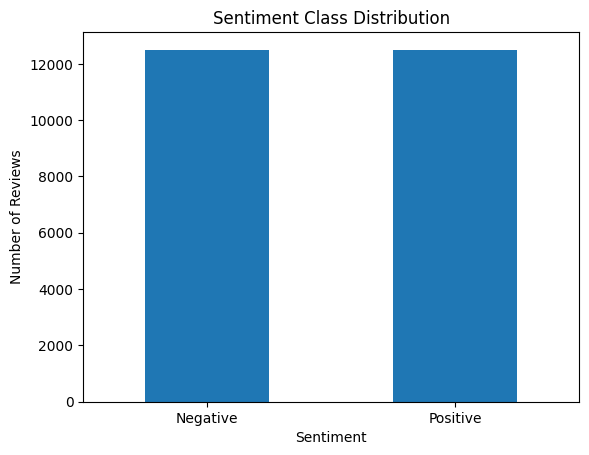


----- BEFORE PREPROCESSING -----
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would re

----- AFTER PREPROCESSING -----
film brilliant casting location scenery story direction everyone really suited part played could imagine robert amazing actor director father came scottish island loved fact real connection film witty remarks throughout film great brilliant much bought film soon released would recommend everyone watch fly fishing amazing really cried end sad know say cry film must good definitely also two little boy played norman paul brilliant 

In [6]:
# Roll No: 24BAD056
# Name: M. Karthik Saravanakumar

# Install required libraries
!pip install -q nltk

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk

from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Download stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords

# 1. LOAD IMDB DATASET
vocab_size = 10000
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = imdb.load_data(
    num_words=vocab_size
)
print("Dataset loaded successfully.")
print("\nNumber of training samples:",
      len(x_train_raw))
print("Number of testing samples:",
      len(x_test_raw))

# 2. CREATE WORD INDEX
word_index = imdb.get_word_index()
reverse_word_index = {
    value + 3: key
    for key, value in word_index.items()
}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"

# 3. CONVERT NUMERICAL REVIEWS INTO TEXT
def decode_review(sequence):
    return " ".join(
        reverse_word_index.get(
            index,
            "<UNK>"
        )
        for index in sequence
    )

# Convert training reviews into text
train_text = [
    decode_review(review)
    for review in x_train_raw
]

# Convert testing reviews into text
test_text = [
    decode_review(review)
    for review in x_test_raw
]

# 4. DISPLAY SAMPLE POSITIVE AND NEGATIVE REVIEWS
print("\n----- SAMPLE NEGATIVE REVIEW -----")
negative_index = np.where(
    y_train_raw == 0
)[0][0]
print(
    train_text[negative_index][:500]
)
print("\nSentiment label: 0 = Negative")
print("\n----- SAMPLE POSITIVE REVIEW -----")
positive_index = np.where(
    y_train_raw == 1
)[0][0]
print(
    train_text[positive_index][:500]
)
print("\nSentiment label: 1 = Positive")

# 5. CHECK DATASET AND CLASS DISTRIBUTION
print("\n----- DATASET INFORMATION -----")
print("Total training samples:",
      len(train_text))
print("Total testing samples:",
      len(test_text))
print("\n----- CLASS DISTRIBUTION -----")
print("Negative reviews:",
      np.sum(y_train_raw == 0))
print("Positive reviews:",
      np.sum(y_train_raw == 1))

# Plot class distribution
pd.Series(
    y_train_raw
).value_counts().plot(
    kind="bar",
    title="Sentiment Class Distribution"
)
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(
    [0, 1],
    ["Negative", "Positive"],
    rotation=0
)
plt.show()

# 6. TEXT PREPROCESSING
stop_words = set(
    stopwords.words("english")
)
def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    # Remove punctuation and special characters
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    # Tokenize into words
    words = text.split()

    # Remove stop words
    words = [
        word
        for word in words
        if word not in stop_words
    ]

    # Join words
    text = " ".join(words)
    return text

# 7. DISPLAY BEFORE AND AFTER PREPROCESSING
print("\n----- BEFORE PREPROCESSING -----")
print(
    train_text[0][:500]
)

# Apply preprocessing to training data
train_clean_text = [
    preprocess_text(text)
    for text in train_text
]

# Apply preprocessing to testing data
test_clean_text = [
    preprocess_text(text)
    for text in test_text
]
print("\n----- AFTER PREPROCESSING -----")
print(
    train_clean_text[0][:500]
)

# 8. TOKENIZATION
vocab_size = 10000
max_length = 200
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)
tokenizer.fit_on_texts(
    train_clean_text
)
print("\n----- TOKENIZATION -----")
print(
    "Vocabulary size:",
    len(tokenizer.word_index)
)

# 9. CONVERT TOKENS INTO NUMERICAL SEQUENCES
x_train_full = tokenizer.texts_to_sequences(
    train_clean_text
)
x_test = tokenizer.texts_to_sequences(
    test_clean_text
)
print("\n----- NUMERICAL SEQUENCE -----")
print(
    x_train_full[0][:30]
)

# 10. APPLY SEQUENCE PADDING
x_train_full = pad_sequences(
    x_train_full,
    maxlen=max_length,
    padding="post",
    truncating="post"
)
x_test = pad_sequences(
    x_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)
print("\n----- PADDING -----")
print(
    "Maximum sequence length:",
    max_length
)
print(
    "Training data shape:",
    x_train_full.shape
)
print(
    "Testing data shape:",
    x_test.shape
)

# 11. ENCODE SENTIMENT LABELS
y_train_full = np.array(
    y_train_raw
)
y_test = np.array(
    y_test_raw
)
print("\n----- SENTIMENT LABEL ENCODING -----")
print("First 10 labels:")
print(
    y_train_full[:10]
)
print("\n0 = Negative")
print("1 = Positive")

# 12. TRAIN / VALIDATION SPLIT
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

# 13. DISPLAY FINAL DATA SHAPES
print("\n----- FINAL DATA SHAPES -----")
print(
    "Training data   :",
    x_train.shape
)
print(
    "Validation data :",
    x_val.shape
)
print(
    "Testing data    :",
    x_test.shape
)
print(
    "\nTraining labels   :",
    y_train.shape
)
print(
    "Validation labels :",
    y_val.shape
)
print(
    "Testing labels    :",
    y_test.shape
)

# 14. PART A COMPLETION MESSAGE
print("\n========================================")
print("PART A COMPLETED SUCCESSFULLY")
print("========================================")

print("Dataset        : IMDB Movie Reviews")
print("Vocabulary     :", vocab_size)
print("Sequence Length:", max_length)
print("Classes        : 2")
print("0 = Negative")
print("1 = Positive")

PART B: EMBEDDING GENERATIONS

In [3]:
# Roll No: 24BAD056
# Name: M. Karthik Saravanakumar

# Import required libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding

# 1. DEFINE EMBEDDING PARAMETERS
embedding_dim = 64
print("----- EMBEDDING PARAMETERS -----")
print("Vocabulary Size        :", vocab_size)
print("Maximum Sequence Length:", max_length)
print("Embedding Dimension    :", embedding_dim)

# 2. CREATE EMBEDDING LAYER
embedding_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    )
])
print("\nEmbedding layer created successfully.")

# 3. SELECT ONE SAMPLE INPUT
sample_input = x_train[:1]
print("\n----- INPUT INFORMATION -----")
print("Input shape:", sample_input.shape)

# 4. GENERATE EMBEDDING REPRESENTATION
embedded_output = embedding_model(sample_input)

# 5. DISPLAY EMBEDDING SHAPE
print("\n----- EMBEDDING OUTPUT -----")
print("Embedding output shape:",
      embedded_output.shape)

# 6. DISPLAY SAMPLE EMBEDDING VECTOR
print("\n----- SAMPLE EMBEDDING VECTOR -----")
print(embedded_output[0, 0, :])

# 7. DISPLAY EMBEDDING INFORMATION
print("\n----- EMBEDDING ANALYSIS -----")
print("Each word is represented using",
      embedding_dim,
      "numerical values.")
print("Each review contains",
      max_length,
      "tokens after padding.")
print("Embedding representation shape:")
print(
    "(Number of samples,",
    max_length,
    ",",
    embedding_dim,
    ")"
)

----- EMBEDDING PARAMETERS -----
Vocabulary Size        : 10000
Maximum Sequence Length: 200
Embedding Dimension    : 64

Embedding layer created successfully.

----- INPUT INFORMATION -----
Input shape: (1, 200)

----- EMBEDDING OUTPUT -----
Embedding output shape: (1, 200, 64)

----- SAMPLE EMBEDDING VECTOR -----
tf.Tensor(
[ 0.03647033  0.02079216  0.04611014  0.02921772 -0.04409367  0.02546758
  0.04643475 -0.03151537 -0.0358078   0.01019662 -0.03659441 -0.03363883
  0.01248356  0.02311026 -0.00220878 -0.04409713 -0.00420459  0.00837526
  0.02497883 -0.0336009   0.0155538   0.0463259   0.00173035 -0.03544779
 -0.03969748 -0.00188717 -0.0104662   0.03386864 -0.01198064  0.04559854
  0.01495108 -0.01210817 -0.02410526  0.04928166  0.01404836 -0.01150137
 -0.01124237 -0.01210356  0.03428138 -0.00928987  0.01315698 -0.0051946
  0.00679509  0.0329793   0.00980913 -0.00943286 -0.03246317 -0.02318115
 -0.00189976  0.04636076 -0.00358791 -0.04029652  0.03107398 -0.01419237
 -0.04918609 -0.

PART C: IMPLEMENTING THE LSTM MODEL

In [4]:
# Roll No: 24BAD056
# Name: M. Karthik Saravanakumar

# Import required libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# 1. DEFINE MODEL PARAMETERS
embedding_dim = 64
lstm_units = 64
print("----- MODEL PARAMETERS -----")
print("Vocabulary Size     :", vocab_size)
print("Embedding Dimension :", embedding_dim)
print("LSTM Units          :", lstm_units)

# 2. CREATE LSTM MODEL
model = Sequential([
    # Embedding Layer
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),
    # LSTM Layer
    LSTM(lstm_units),
    # Dense Output Layer
    Dense(
        1,
        activation="sigmoid"
    )
])

# 3. COMPILE THE MODEL
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 4. DISPLAY MODEL ARCHITECTURE
print("\n----- MODEL SUMMARY -----")
model.summary()

# 5. DISPLAY MODEL CONFIGURATION
print("\n----- MODEL CONFIGURATION -----")
print("Optimizer         : Adam")
print("Loss Function     : Binary Cross-Entropy")
print("Evaluation Metric : Accuracy")
print("Output Activation : Sigmoid")

# 6. DISPLAY MODEL FLOW
print("\n----- MODEL FLOW -----")
print("Input Sequence")
print("      ↓")
print("Embedding Layer")
print("      ↓")
print("LSTM Layer")
print("      ↓")
print("Dense Layer")
print("      ↓")
print("Sigmoid Activation")
print("      ↓")
print("Positive / Negative")

----- MODEL PARAMETERS -----
Vocabulary Size     : 10000
Embedding Dimension : 64
LSTM Units          : 64

----- MODEL SUMMARY -----


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


----- MODEL CONFIGURATION -----
Optimizer         : Adam
Loss Function     : Binary Cross-Entropy
Evaluation Metric : Accuracy
Output Activation : Sigmoid

----- MODEL FLOW -----
Input Sequence
      ↓
Embedding Layer
      ↓
LSTM Layer
      ↓
Dense Layer
      ↓
Sigmoid Activation
      ↓
Positive / Negative


PART D: MODEL TRAINING AND SENTIMENT PREDICTION

----- MODEL TRAINING -----
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.5056 - loss: 0.6932 - val_accuracy: 0.5138 - val_loss: 0.6923
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5271 - loss: 0.6902 - val_accuracy: 0.5220 - val_loss: 0.6911
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5557 - loss: 0.6640 - val_accuracy: 0.5212 - val_loss: 0.7000
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5569 - loss: 0.6588 - val_accuracy: 0.5280 - val_loss: 0.6949
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5588 - loss: 0.6284 - val_accuracy: 0.5326 - val_loss: 0.7227

----- TRAINING RESULTS -----
Training Accuracy  : 0.5588499903678894
Validation Accuracy: 0.5325999855995178
Training Loss      : 0.6284037828445435
Validation Loss    : 0.72272127866745


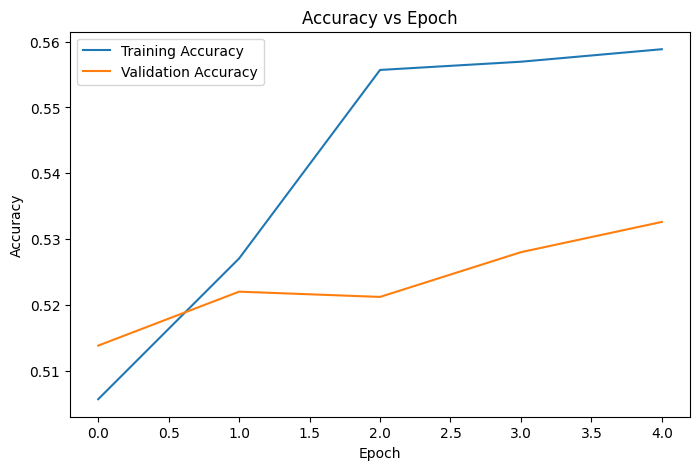

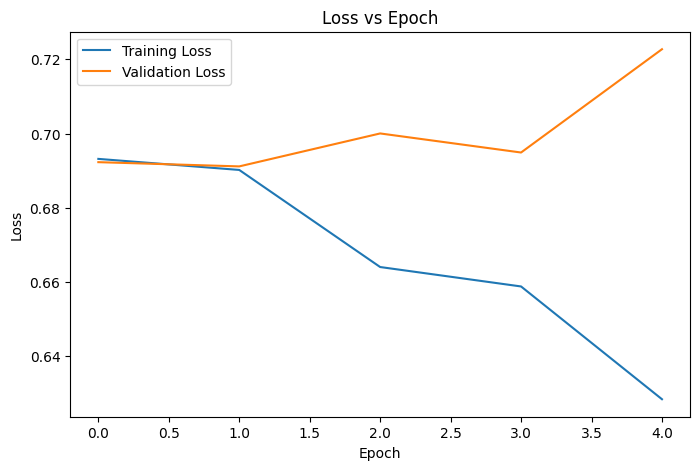


----- TEST DATA EVALUATION -----
Test Loss    : 0.7205265760421753
Test Accuracy: 0.5228800177574158

----- TEST DATA PREDICTION -----
Prediction completed.

----- ACTUAL VS PREDICTED LABELS -----
Actual labels:
[0 1 1 0 1 1 1 0 0 1 1 0 0 0 1 0 1 0 0 0]

Predicted labels:
[0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0]

----- SENTIMENT COMPARISON -----
      Actual Predicted
0   Negative  Negative
1   Positive  Negative
2   Positive  Positive
3   Negative  Negative
4   Positive  Negative
5   Positive  Negative
6   Positive  Positive
7   Negative  Negative
8   Negative  Negative
9   Positive  Positive
10  Positive  Negative
11  Negative  Negative
12  Negative  Negative
13  Negative  Negative
14  Positive  Negative
15  Negative  Negative
16  Positive  Negative
17  Negative  Negative
18  Negative  Negative
19  Negative  Negative

===== MODEL PERFORMANCE =====
Accuracy : 0.5229
Precision: 0.6022
Recall   : 0.1348
F1-Score : 0.2203

----- CONFUSION MATRIX -----
[[11387  1113]
 [10815  1685]]


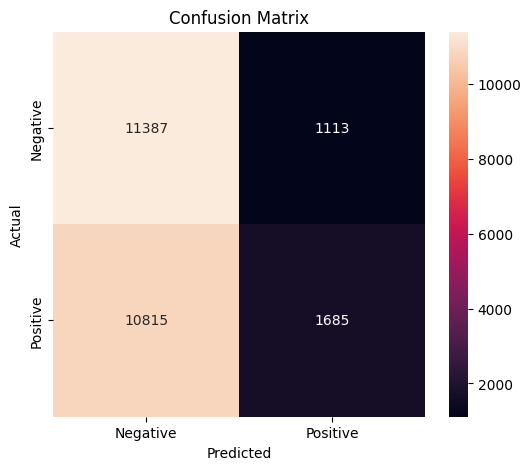


----- CLASSIFICATION REPORT -----
              precision    recall  f1-score   support

    Negative       0.51      0.91      0.66     12500
    Positive       0.60      0.13      0.22     12500

    accuracy                           0.52     25000
   macro avg       0.56      0.52      0.44     25000
weighted avg       0.56      0.52      0.44     25000


===== NEW REVIEW SENTIMENT PREDICTION =====

Review: This movie was excellent and very enjoyable
Predicted Sentiment: Negative
Prediction Score: 0.4964

Review: The movie was boring and disappointing
Predicted Sentiment: Negative
Prediction Score: 0.4964

Review: I really loved the story and the acting
Predicted Sentiment: Negative
Prediction Score: 0.4964

Review: The film was terrible and a waste of time
Predicted Sentiment: Negative
Prediction Score: 0.4964


In [5]:
# Roll No: 24BAD056
# Name: M. Karthik Saravanakumar

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns

# 1. TRAIN THE LSTM MODEL
print("----- MODEL TRAINING -----")
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=5,
    batch_size=128
)

# 2. DISPLAY TRAINING RESULTS
print("\n----- TRAINING RESULTS -----")
training_accuracy = history.history["accuracy"][-1]
validation_accuracy = history.history["val_accuracy"][-1]
training_loss = history.history["loss"][-1]
validation_loss = history.history["val_loss"][-1]

print("Training Accuracy  :", training_accuracy)
print("Validation Accuracy:", validation_accuracy)
print("Training Loss      :", training_loss)
print("Validation Loss    :", validation_loss)

# 3. ACCURACY VS EPOCH
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

# 4. LOSS VS EPOCH
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

# 5. EVALUATE MODEL USING TEST DATA
print("\n----- TEST DATA EVALUATION -----")
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)
print("Test Loss    :", test_loss)
print("Test Accuracy:", test_accuracy)

# 6. PREDICT TEST DATA
print("\n----- TEST DATA PREDICTION -----")
y_probability = model.predict(
    x_test,
    verbose=0
)
# Convert probability into class label
y_pred = (
    y_probability >= 0.5
).astype(int).flatten()
print("Prediction completed.")

# 7. DISPLAY ACTUAL AND PREDICTED LABELS
print("\n----- ACTUAL VS PREDICTED LABELS -----")
print("Actual labels:")
print(y_test[:20])
print("\nPredicted labels:")
print(y_pred[:20])

# 8. COMPARE ACTUAL AND PREDICTED SENTIMENT
sentiment_names = {
    0: "Negative",
    1: "Positive"
}
comparison = pd.DataFrame({
    "Actual": [
        sentiment_names[x]
        for x in y_test[:20]
    ],
    "Predicted": [
        sentiment_names[x]
        for x in y_pred[:20]
    ]
})
print("\n----- SENTIMENT COMPARISON -----")
print(comparison)

# 9. CALCULATE ACCURACY
accuracy = accuracy_score(
    y_test,
    y_pred
)

# 10. CALCULATE PRECISION
precision = precision_score(
    y_test,
    y_pred
)

# 11. CALCULATE RECALL
recall = recall_score(
    y_test,
    y_pred
)

# 12. CALCULATE F1-SCORE
f1 = f1_score(
    y_test,
    y_pred
)

# 13. DISPLAY EVALUATION METRICS
print("\n===== MODEL PERFORMANCE =====")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

# 14. CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    y_pred
)
print("\n----- CONFUSION MATRIX -----")
print(cm)

# 15. VISUALIZE CONFUSION MATRIX
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Negative",
        "Positive"
    ],
    yticklabels=[
        "Negative",
        "Positive"
    ]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 16. CLASSIFICATION REPORT
print("\n----- CLASSIFICATION REPORT -----")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

# 17. FUNCTION FOR NEW REVIEW PREDICTION
def predict_sentiment(review):
    # Preprocess the review
    cleaned_review = preprocess_text(
        review
    )
    # Convert review into numerical sequence
    sequence = tokenizer.texts_to_sequences(
        [cleaned_review]
    )
    # Apply padding
    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_length,
        padding="post",
        truncating="post"
    )
    # Predict sentiment
    probability = model.predict(
        padded_sequence,
        verbose=0
    )[0][0]
    # Classify sentiment
    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"
    return sentiment, probability

# 18. SAMPLE REVIEW PREDICTIONS
sample_reviews = [
    "This movie was excellent and very enjoyable",
    "The movie was boring and disappointing",
    "I really loved the story and the acting",
    "The film was terrible and a waste of time"
]
print("\n===== NEW REVIEW SENTIMENT PREDICTION =====")
for review in sample_reviews:
    sentiment, probability = (
        predict_sentiment(review)
    )
    print("\nReview:", revie)
    print(
        "Predicted Sentiment:",
        sentiment
    )
    print(
        "Prediction Score:",
        round(probability, 4)
    )